# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [14]:
# count(*)
len(df)

144015

Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [15]:
df.columns = df.columns.str.lower()

In [16]:
df.head()

,trip id,duration,start date,start station,start terminal,end date,end station,end terminal,bike #,subscription type,zip code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


In [17]:
df.columns = df.columns.str.replace('#', 'num')

In [22]:
df.columns = df.columns.str.replace(' ', '_')

In [23]:
df.head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


In [18]:
df[df.columns[df.columns.str.contains('bike')]]

,bike num
0,520
1,661
2,48
3,26
4,319
...,...
144010,483
144011,425
144012,438
144013,414


How many types of subscription options are there? What are the different subscription types?

In [26]:
# select distinct Subscription Type
print(df['subscription_type'].unique())

<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str


In [27]:
# select COUNT(distinct Subscription Type)
print(df['subscription_type'].nunique())

2


What is the frequency of each subscription option?

In [28]:
df['subscription_type'].value_counts(normalize=True)

subscription_type
Subscriber    0.789133
Customer      0.210867
Name: proportion, dtype: float64

Please plot the frequency of each subscription option with a pie chart:

<Axes: >

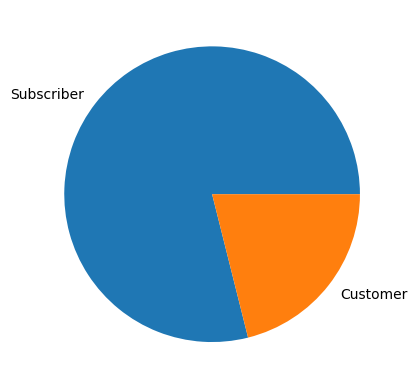

In [29]:
df['subscription_type'].value_counts().plot(kind='pie')

Please plot the frequency of each subscription option with a bar chart:

<Axes: xlabel='subscription_type'>

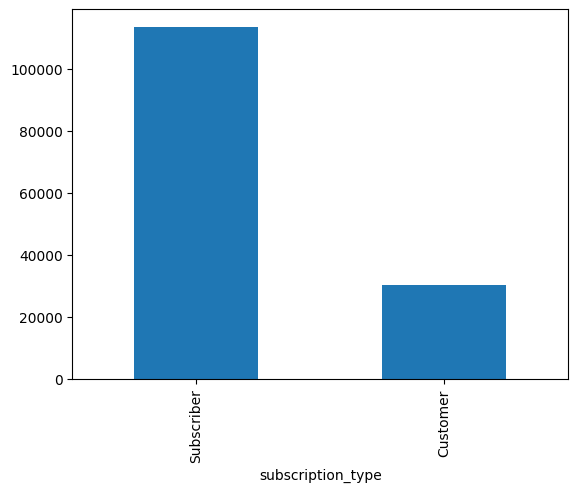

In [30]:
df['subscription_type'].value_counts().plot(kind='bar')

Have a look at the start_station column: Which 10 stations occur most frequently?

In [32]:
df['start_station'].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [34]:
df['start_station'].value_counts().tail(10)

start_station
Park at Olive                       189
Castro Street and El Camino Real    132
Redwood City Medical Center         123
San Antonio Shopping Center         108
San Mateo County Center             101
Franklin at Maple                    99
Broadway at Main                     45
Redwood City Public Library          44
San Jose Government Center           23
Mezes Park                            3
Name: count, dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [36]:
#SELECT start_station, SUM(CASE WHEN subscription_type = 'Customer' THEN 1 ELSE 0 END) AS Customer, SUM(CASE WHEN subscription_type = 'Subscriber' THEN 1 ELSE 0 END) AS Subscriber, COUNT(*) AS total FROM table GROUP BY start_station
pd.crosstab(df['start_station'], df['subscription_type'], margins=True)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [ ]:
#looks like seconds

In [37]:
#convert string to datetime format
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

In [38]:
#create a new trip_duration column by calculating
df['trip_duration'] = df['end_date'] - df['start_date']

In [39]:
df.head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code,trip_duration
0,4576,63,2013-08-29 14:13:00,South Van Ness at Market,66,2013-08-29 14:14:00,South Van Ness at Market,66,520,Subscriber,94127,0 days 00:01:00
1,4607,70,2013-08-29 14:42:00,San Jose City Hall,10,2013-08-29 14:43:00,San Jose City Hall,10,661,Subscriber,95138,0 days 00:01:00
2,4130,71,2013-08-29 10:16:00,Mountain View City Hall,27,2013-08-29 10:17:00,Mountain View City Hall,27,48,Subscriber,97214,0 days 00:01:00
3,4251,77,2013-08-29 11:29:00,San Jose City Hall,10,2013-08-29 11:30:00,San Jose City Hall,10,26,Subscriber,95060,0 days 00:01:00
4,4299,83,2013-08-29 12:02:00,South Van Ness at Market,66,2013-08-29 12:04:00,Market at 10th,67,319,Subscriber,94103,0 days 00:02:00


In [40]:
#shortest trip
df.sort_values('trip_duration').head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code,trip_duration
0,4576,63,2013-08-29 14:13:00,South Van Ness at Market,66,2013-08-29 14:14:00,South Van Ness at Market,66,520,Subscriber,94127,0 days 00:01:00
50297,71275,64,2013-10-24 19:54:00,Market at 10th,67,2013-10-24 19:55:00,Market at 10th,67,621,Subscriber,94105,0 days 00:01:00
120368,166722,112,2014-01-27 07:55:00,Temporary Transbay Terminal (Howard at Beale),55,2014-01-27 07:56:00,Howard at 2nd,63,434,Subscriber,94602,0 days 00:01:00
10457,18792,60,2013-09-12 10:09:00,Civic Center BART (7th at Market),72,2013-09-12 10:10:00,Civic Center BART (7th at Market),72,632,Subscriber,94103,0 days 00:01:00
71051,98620,81,2013-11-16 15:52:00,Embarcadero at Folsom,51,2013-11-16 15:53:00,Embarcadero at Folsom,51,287,Customer,94116,0 days 00:01:00


In [42]:
len(df[df['trip_duration'] == pd.Timedelta('1 minute')])

463

What do you think is going on with the short trips?

In [ ]:
# they seem to start and end at the same station, looks like corrupted data if you ask me

What is the longest trip?

In [ ]:
#same as before, just descending
df.sort_values('trip_duration', ascending=False).head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code,trip_duration
80510,111309,722236,2013-11-30 13:29:00,University and Emerson,35,2013-12-08 22:06:00,University and Emerson,35,247,Customer,94301,8 days 08:37:00
93400,129504,619322,2013-12-18 09:16:00,San Jose Diridon Caltrain Station,2,2013-12-25 13:18:00,SJSU 4th at San Carlos,12,653,Subscriber,94041,7 days 04:02:00
20535,32121,597517,2013-09-23 18:24:00,California Ave Caltrain Station,36,2013-09-30 16:23:00,Palo Alto Caltrain Station,34,168,Customer,95051,6 days 21:59:00
119830,166010,586356,2014-01-25 20:00:00,San Antonio Caltrain Station,29,2014-02-01 14:53:00,San Antonio Caltrain Station,29,693,Customer,94303,6 days 18:53:00
43549,62246,429384,2013-10-17 16:06:00,Davis at Jackson,42,2013-10-22 15:23:00,Powell Street BART,39,465,Customer,43113,4 days 23:17:00


How would you define a "long" trip? How many trips are "long" according to your definition?

In [ ]:
# since the longest is one hour, i'd take any trip longer than 30 minutes to be long
# select count(*) from table where trip_duration > 30 minutes
len(df[df['trip_duration'] > pd.Timedelta(minutes=30)])

9110

Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

In [46]:
df.sort_values('trip_duration', ascending=False).head(10)

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code,trip_duration
80510,111309,722236,2013-11-30 13:29:00,University and Emerson,35,2013-12-08 22:06:00,University and Emerson,35,247,Customer,94301,8 days 08:37:00
93400,129504,619322,2013-12-18 09:16:00,San Jose Diridon Caltrain Station,2,2013-12-25 13:18:00,SJSU 4th at San Carlos,12,653,Subscriber,94041,7 days 04:02:00
20535,32121,597517,2013-09-23 18:24:00,California Ave Caltrain Station,36,2013-09-30 16:23:00,Palo Alto Caltrain Station,34,168,Customer,95051,6 days 21:59:00
119830,166010,586356,2014-01-25 20:00:00,San Antonio Caltrain Station,29,2014-02-01 14:53:00,San Antonio Caltrain Station,29,693,Customer,94303,6 days 18:53:00
43549,62246,429384,2013-10-17 16:06:00,Davis at Jackson,42,2013-10-22 15:23:00,Powell Street BART,39,465,Customer,43113,4 days 23:17:00
24068,36617,329456,2013-09-26 20:51:00,Park at Olive,38,2013-09-30 16:22:00,Palo Alto Caltrain Station,34,162,Customer,94306,3 days 19:31:00
12725,21760,309479,2013-09-14 18:21:00,SJSU 4th at San Carlos,12,2013-09-18 08:19:00,SJSU - San Salvador at 9th,16,242,Customer,95112,3 days 13:58:00
108144,150269,303271,2014-01-11 20:16:00,Civic Center BART (7th at Market),72,2014-01-15 08:31:00,Civic Center BART (7th at Market),72,538,Customer,94110,3 days 12:15:00
100174,138946,296045,2013-12-31 09:43:00,Rengstorff Avenue / California Street,33,2014-01-03 19:57:00,Rengstorff Avenue / California Street,33,217,Customer,NaN,3 days 10:14:00
80086,110706,280439,2013-11-29 11:33:00,Post at Kearney,47,2013-12-02 17:27:00,Market at Sansome,77,593,Customer,33141,3 days 05:54:00


In [ ]:
# long trips are made by customers, not subscribers, perhaps these are tourists.

Plot the duration column.

<Axes: >

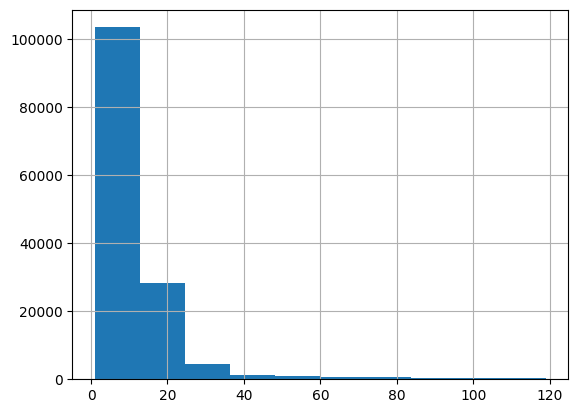

In [50]:
df[df['trip_duration_min'] < 120]['trip_duration_min'].hist()

Does this plot give any insights?

In [ ]:
#shows that not many people are taking longer trips

Select subsections of the data to make plots that provide more insights.

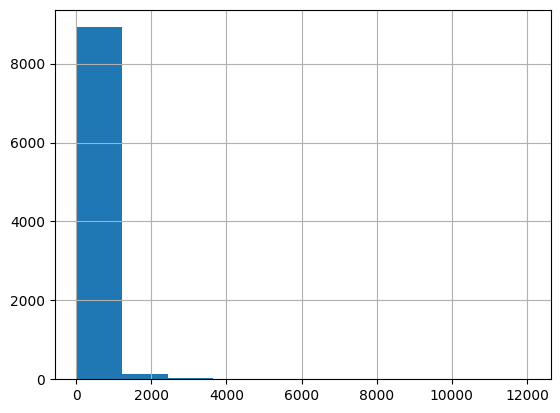

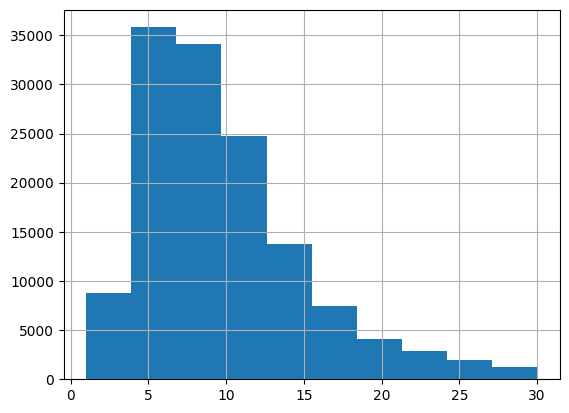

In [ ]:
import matplotlib.pyplot as plt

long_trips['trip_duration_min'].hist()
plt.show()

short_trips['trip_duration_min'].hist()
plt.show()

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [54]:
df['start_station'] = df['start_station'].str.lower().str.replace(' ', '_')

In [55]:
df.head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code,trip_duration,trip_duration_min
0,4576,63,2013-08-29 14:13:00,south_van_ness_at_market,66,2013-08-29 14:14:00,South Van Ness at Market,66,520,Subscriber,94127,0 days 00:01:00,1.0
1,4607,70,2013-08-29 14:42:00,san_jose_city_hall,10,2013-08-29 14:43:00,San Jose City Hall,10,661,Subscriber,95138,0 days 00:01:00,1.0
2,4130,71,2013-08-29 10:16:00,mountain_view_city_hall,27,2013-08-29 10:17:00,Mountain View City Hall,27,48,Subscriber,97214,0 days 00:01:00,1.0
3,4251,77,2013-08-29 11:29:00,san_jose_city_hall,10,2013-08-29 11:30:00,San Jose City Hall,10,26,Subscriber,95060,0 days 00:01:00,1.0
4,4299,83,2013-08-29 12:02:00,south_van_ness_at_market,66,2013-08-29 12:04:00,Market at 10th,67,319,Subscriber,94103,0 days 00:02:00,2.0


In [56]:
df['end_station'] = df['end_station'].str.lower().str.replace(' ', '_')

In [57]:
df.head()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code,trip_duration,trip_duration_min
0,4576,63,2013-08-29 14:13:00,south_van_ness_at_market,66,2013-08-29 14:14:00,south_van_ness_at_market,66,520,Subscriber,94127,0 days 00:01:00,1.0
1,4607,70,2013-08-29 14:42:00,san_jose_city_hall,10,2013-08-29 14:43:00,san_jose_city_hall,10,661,Subscriber,95138,0 days 00:01:00,1.0
2,4130,71,2013-08-29 10:16:00,mountain_view_city_hall,27,2013-08-29 10:17:00,mountain_view_city_hall,27,48,Subscriber,97214,0 days 00:01:00,1.0
3,4251,77,2013-08-29 11:29:00,san_jose_city_hall,10,2013-08-29 11:30:00,san_jose_city_hall,10,26,Subscriber,95060,0 days 00:01:00,1.0
4,4299,83,2013-08-29 12:02:00,south_van_ness_at_market,66,2013-08-29 12:04:00,market_at_10th,67,319,Subscriber,94103,0 days 00:02:00,2.0


Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 

In [60]:
# from which station do people take the long trips
long_trips['start_station'].value_counts().head(10)

start_station
Harry Bridges Plaza (Ferry Building)    1031
Embarcadero at Sansome                   732
Market at 4th                            450
Embarcadero at Vallejo                   383
Powell at Post (Union Square)            346
Market at Sansome                        324
Powell Street BART                       315
Steuart at Market                        265
Embarcadero at Bryant                    258
Grant Avenue at Columbus Avenue          254
Name: count, dtype: int64

In [59]:
# what is the most popular end station
df['end_station'].value_counts().head(1)

end_station
san_francisco_caltrain_(townsend_at_4th)    11637
Name: count, dtype: int64